# Energy Consumption Prediction and Household Segmentation in Zurich
**Dataset**: HEAPO – Heat Pump Optimization Dataset.

**Predict monthly electricity consumption per household.**

Ich möchte den Energieverbrauch von Haushalten mit dem HEAPO-Datensatz vorhersagen (Zürich, 1.408 Haushalte, Zeitreihen + einige Haushalts- und Wetterdaten).
 
**Plan**:
 
Regression (Linear Regression, Random Forest)
 
Klassifikation (Verbrauchskategorien)
 
Clustering (K-Means, optional)

### Imports
**Note:** Before running the script, ensure that `data_path` is set to the correct location of the stored data.

In [5]:
# ----------------------
# IMPORT OTHER PACKAGES 
# ----------------------
import os 
import sys
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.dates as mdates
plt.rcParams["font.family"] = "sans-serif"

# ----------------------
# IMPORT HEAPO SCRIPTS
# ----------------------

# either run script heapo.py inside the src folder
# folder_path = os.path.dirname(os.getcwd())+'/src/'
# %run -i {folder_path + 'heapo.py'}

# or import heapo as a package - RECOMMENDED because Visual Studio Code then recognizes the package
folder_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0,'/Users/svetlana/Documents/CAS_ML/Project/heapo-main/src')
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------

# NOTE: if data is stored under /data/ within this repository --> set data_path = None 
data_path = '/Users/svetlana/Documents/CAS_ML/Project/heapo_data/'

# otherwise please provide the absolute path to the HEAPO dataset including the last slash
# data_path = '/Users/user/path/to/heapo_data/'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------

# create HEAPO object
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

## Problem Definition
**Task**: Predict monthly electricity consumption per household

**Input features**:

Weather (outdoor temperatures)

Living area (m2)

Number of residents

Heat pump type

Appliances:
EV (yes/no)
Dryer (yes/no)
Freezer (yes/no)etc

**Target**:
Monthly electricity consumption (kWh)

### Dataset Preparation

I need to aggregate the time-series into monthly values

In [14]:
df_meta = heapo.get_meta_data_overview()
df_meta.count()

Household_ID                                   1408
Group                                          1408
Weather_ID                                     1408
Installation_HasPVSystem                        650
Protocols_Available                            1408
Protocols_HasMultipleVisits                    1408
Protocols_ReportIDs                             214
MetaData_Available                             1408
SmartMeterData_Available_15min                 1408
SmartMeterData_Available_Daily                 1408
SmartMeterData_Available_Monthly               1408
Survey_Building_Type                           1356
Survey_Building_LivingArea                     1339
Survey_Building_Residents                      1348
Survey_HeatPump_Installation_Type              1354
Survey_HeatDistribution_System_FloorHeating    1310
Survey_HeatDistribution_System_Radiator        1310
Survey_DHW_Production_ByHeatPump                851
Survey_DHW_Production_ByElectricWaterHeater     424
Survey_DHW_P

In [15]:
df_meta = df_meta[
    ['Household_ID',
     'Weather_ID',
     'Survey_Building_Residents',
     'Survey_Building_LivingArea',
     'Survey_HeatPump_Installation_Type',
     'Survey_HeatDistribution_System_FloorHeating',
     'Survey_HeatDistribution_System_Radiator',
     'Survey_Installation_HasElectricVehicle',
     'Survey_Installation_HasFreezer',
     'Survey_Installation_HasDryer',
    ]
]
df_meta = df_meta.rename(columns=lambda x: x.replace('Survey_', ''))
df_meta.head()

,Household_ID,Weather_ID,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer
0,1060,8jB,2.0,180.0,air-source,True,False,False,True,True
1,10266,z6I,2.0,240.0,air-source,False,True,True,True,True
2,11769,Hg,1.0,200.0,air-source,True,False,False,True,True
3,24611,sV3mR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65651,HbsbG,2.0,180.0,air-source,False,True,False,True,False


In [47]:
# Export dataframe to Parquet file
df_meta.to_parquet("df_meta.parquet", index=False)

In [36]:
def load_smart_meter_data_multiple_safe(household_ids):
    #df_final = pd.DataFrame()
    df_list = []
    for idx, hid in enumerate(household_ids):
        try:
            df = heapo.load_smart_meter_data(hid, resolution='15min')
            df.drop(['AffectsTimePoint', 'Group', 'kWh_received_HeatPump', 'kWh_received_Other'], inplace=True, axis=1,)
            if df is not None: 
                df['Timestamp'] = pd.to_datetime(df['Timestamp'])
                df =df.set_index('Timestamp')
                df_hourly = df.resample('h').sum()
                df_hourly["Household_ID"] = hid
                df_hourly = df_hourly.reset_index()
                
                df_list.append(df_hourly)
                #df_final = pd.concat([df_final, df], axis=0)
        except Exception as e:
            print(f'{hid} error', e)
            pass
        if idx % 100 == 0:
            print(idx, len(houshold_ids))
    df_final = pd.concat(df_list, axis=0)
    df_final.drop_duplicates(inplace=True)
    df_final.reset_index(drop=True, inplace=True)
    if heapo.use_local_time: 
        df_final = heapo.__convert_UTC_to_local_time__(df_final, inplace=True)
    return df_final

houshold_ids = df_meta['Household_ID'].tolist()
#houshold_ids

In [37]:
df_smart_meter = load_smart_meter_data_multiple_safe(houshold_ids)
df_smart_meter

0 1408
100 1408
200 1408
300 1408
400 1408
488170 error HEAPO.load_smart_meter_data(): File for given household (488170) cannot be found: /Users/svetlana/Documents/CAS_ML/Project/heapo_data/smart_meter_data/15min/488170.csv
500 1408
600 1408
700 1408
800 1408
900 1408
1000 1408
1100 1408
1200 1408
1300 1408
1400 1408


,Timestamp,Household_ID,kWh_received_Total
0,2022-05-26 00:00:00+00:00,1060,3.201
1,2022-05-26 01:00:00+00:00,1060,3.428
2,2022-05-26 02:00:00+00:00,1060,1.959
3,2022-05-26 03:00:00+00:00,1060,1.883
4,2022-05-26 04:00:00+00:00,1060,0.961
...,...,...,...
22838395,2024-02-27 19:00:00+00:00,9981041,2.104
22838396,2024-02-27 20:00:00+00:00,9981041,1.787
22838397,2024-02-27 21:00:00+00:00,9981041,1.380
22838398,2024-02-27 22:00:00+00:00,9981041,1.204


In [44]:
df_smart_meter['Household_ID'].unique().shape

(1407,)

In [49]:
# Export dataframe to Parquet file
df_smart_meter.to_parquet("df_smart_meter.parquet", coerce_timestamps='ms',index=False)

In [41]:
def weather_for_weather_id(weather_id):
    weather = heapo.load_weather_data(weather_id, resolution='hourly')
    # Optional: keep only needed columns
    weather = weather[["Timestamp", "Temperature_avg_hourly","Weather_ID"]]
    return weather

def load_weather_data_safe(weather_ids):
    df_final = pd.DataFrame()
    for w in weather_ids:
        try:
            df = weather_for_weather_id(w)
            if df is not None: 
                df_final = pd.concat([df_final, df], axis=0)
        except Exception as e:
            print(f'{hid} error', e)
            #pass
    df_final.drop_duplicates(inplace=True)
    df_final.reset_index(drop=True, inplace=True)
    return df_final


df_weather = load_weather_data_safe(df_meta_col['Weather_ID'].unique())


In [42]:
df_weather

,Timestamp,Temperature_avg_hourly,Weather_ID
0,2019-01-01 00:00:00+00:00,4.8,8jB
1,2019-01-01 01:00:00+00:00,4.5,8jB
2,2019-01-01 02:00:00+00:00,4.3,8jB
3,2019-01-01 03:00:00+00:00,4.2,8jB
4,2019-01-01 04:00:00+00:00,4.2,8jB
...,...,...,...
362107,2024-02-29 19:00:00+00:00,3.1,MqO
362108,2024-02-29 20:00:00+00:00,2.4,MqO
362109,2024-02-29 21:00:00+00:00,2.2,MqO
362110,2024-02-29 22:00:00+00:00,2.2,MqO


In [50]:
# Export dataframe to Parquet file
df_weather.to_parquet("df_weather.parquet",coerce_timestamps='ms', index=False)

In [52]:
df_meta_tmp = df_meta[['Household_ID', 'kWh_received_Total', 'Timestamp']].copy()

df_meta_tmp["Timestamp"] = pd.to_datetime(df_meta_tmp["Timestamp"])

df_meta_2 = df_meta_tmp.copy()
df_meta_2

,Household_ID,kWh_received_Total,Timestamp
0,1060,15.58,2022-04-15 23:59:59+00:00
1,1060,20.22,2022-04-16 23:59:59+00:00
2,1060,26.80,2022-04-17 23:59:59+00:00
3,1060,25.84,2022-04-18 23:59:59+00:00
4,1060,28.78,2022-04-19 23:59:59+00:00
...,...,...,...
936021,9981041,27.59,2024-03-16 23:59:59+00:00
936022,9981041,31.80,2024-03-17 23:59:59+00:00
936023,9981041,34.72,2024-03-18 23:59:59+00:00
936024,9981041,25.05,2024-03-19 23:59:59+00:00


In [9]:
# merge with Household Metadata
merge1_df = df_meta_2.merge(df_meta_col, on = 'Household_ID', how = 'left')
final_df = merge1_df.merge(df_weather, on = ['Household_ID', 'month'], how = 'left')
final_df.info()
final_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13758 entries, 0 to 13757
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Household_ID                          13758 non-null  int64  
 1   month                                 13758 non-null  int32  
 2   kWh_received_Total                    13559 non-null  float64
 3   Building_Residents                    13528 non-null  float64
 4   Building_LivingArea                   13461 non-null  float64
 5   HeatPump_Installation_Type            13590 non-null  object 
 6   HeatDistribution_System_FloorHeating  13240 non-null  object 
 7   HeatDistribution_System_Radiator      13240 non-null  object 
 8   Installation_HasElectricVehicle       12124 non-null  object 
 9   Installation_HasFreezer               13538 non-null  object 
 10  Installation_HasDryer                 13538 non-null  object 
 11  monthly_avg_tem

,Household_ID,month,kWh_received_Total,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,1,1184.615,2.0,180.0,air-source,True,False,False,True,True,1.752151
1,1060,2,877.060,2.0,180.0,air-source,True,False,False,True,True,4.613609
2,1060,3,2329.530,2.0,180.0,air-source,True,False,False,True,True,6.396129
3,1060,4,1559.840,2.0,180.0,air-source,True,False,False,True,True,9.535333
4,1060,5,563.665,2.0,180.0,air-source,True,False,False,True,True,13.336774
5,1060,6,404.425,2.0,180.0,air-source,True,False,False,True,True,19.032667
6,1060,7,427.720,2.0,180.0,air-source,True,False,False,True,True,20.214839
7,1060,8,430.370,2.0,180.0,air-source,True,False,False,True,True,19.405806
8,1060,9,436.560,2.0,180.0,air-source,True,False,False,True,True,15.881333
9,1060,10,556.405,2.0,180.0,air-source,True,False,False,True,True,11.210968


In [10]:
# missing values
final_df.isnull().sum()

Household_ID                               0
month                                      0
kWh_received_Total                       199
Building_Residents                       230
Building_LivingArea                      297
HeatPump_Installation_Type               168
HeatDistribution_System_FloorHeating     518
HeatDistribution_System_Radiator         518
Installation_HasElectricVehicle         1634
Installation_HasFreezer                  220
Installation_HasDryer                    220
monthly_avg_temp                           0
dtype: int64

In [11]:
final_df['kWh_received_Total'].describe()

count    13559.000000
mean       835.595001
std        615.275680
min          3.335000
25%        412.673333
50%        700.504000
75%       1114.582500
max      11049.753333
Name: kWh_received_Total, dtype: float64

In [12]:
df = final_df.dropna(subset=['kWh_received_Total'])
df.isnull().sum()

Household_ID                               0
month                                      0
kWh_received_Total                         0
Building_Residents                       219
Building_LivingArea                      286
HeatPump_Installation_Type               157
HeatDistribution_System_FloorHeating     505
HeatDistribution_System_Radiator         505
Installation_HasElectricVehicle         1587
Installation_HasFreezer                  209
Installation_HasDryer                    209
monthly_avg_temp                           0
dtype: int64

In [13]:
df

,Household_ID,month,kWh_received_Total,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,1,1184.615,2.0,180.0,air-source,True,False,False,True,True,1.752151
1,1060,2,877.060,2.0,180.0,air-source,True,False,False,True,True,4.613609
2,1060,3,2329.530,2.0,180.0,air-source,True,False,False,True,True,6.396129
3,1060,4,1559.840,2.0,180.0,air-source,True,False,False,True,True,9.535333
4,1060,5,563.665,2.0,180.0,air-source,True,False,False,True,True,13.336774
...,...,...,...,...,...,...,...,...,...,...,...,...
13753,9981041,8,453.810,3.0,360.0,ground-source,True,False,NaN,True,False,19.467097
13754,9981041,9,453.860,3.0,360.0,ground-source,True,False,NaN,True,False,16.220000
13755,9981041,10,844.160,3.0,360.0,ground-source,True,False,NaN,True,False,11.617419
13756,9981041,11,1236.100,3.0,360.0,ground-source,True,False,NaN,True,False,6.015333


In [14]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11528 entries, 0 to 13745
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Household_ID                          11528 non-null  int64  
 1   month                                 11528 non-null  int32  
 2   kWh_received_Total                    11528 non-null  float64
 3   Building_Residents                    11528 non-null  float64
 4   Building_LivingArea                   11528 non-null  float64
 5   HeatPump_Installation_Type            11528 non-null  object 
 6   HeatDistribution_System_FloorHeating  11528 non-null  object 
 7   HeatDistribution_System_Radiator      11528 non-null  object 
 8   Installation_HasElectricVehicle       11528 non-null  object 
 9   Installation_HasFreezer               11528 non-null  object 
 10  Installation_HasDryer                 11528 non-null  object 
 11  monthly_avg_temp    

In [15]:
df.isna().sum()

Household_ID                            0
month                                   0
kWh_received_Total                      0
Building_Residents                      0
Building_LivingArea                     0
HeatPump_Installation_Type              0
HeatDistribution_System_FloorHeating    0
HeatDistribution_System_Radiator        0
Installation_HasElectricVehicle         0
Installation_HasFreezer                 0
Installation_HasDryer                   0
monthly_avg_temp                        0
dtype: int64

In [16]:
df['HeatPump_Installation_Type'].value_counts()

HeatPump_Installation_Type
air-source       6421
ground-source    5107
Name: count, dtype: int64

In [17]:
df['HeatPump_Installation_Type'] = df['HeatPump_Installation_Type'].map({
    'air-source': 0,
    'ground-source': 1
})


/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_10843/1714013267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HeatPump_Installation_Type'] = df['HeatPump_Installation_Type'].map({


In [18]:
bool_cols = ['HeatDistribution_System_FloorHeating',
             'HeatDistribution_System_Radiator',
     'Installation_HasElectricVehicle',
     'Installation_HasFreezer',
     'Installation_HasDryer',
            ]
for col in bool_cols:
    df[col] = df[col].astype(float)


/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_10843/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(float)
/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_10843/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(float)
/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_10843/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

In [19]:
df.drop(columns=['month'], inplace=True)

/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_10843/1558433883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['month'], inplace=True)


In [20]:
#df = df[df['kWh_received_Total'] < 6000]
#Handle outliers
df = df[df['kWh_received_Total'] < df['kWh_received_Total'].quantile(0.99)]
df

,Household_ID,kWh_received_Total,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,1184.615,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,1.752151
1,1060,877.060,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,4.613609
2,1060,2329.530,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,6.396129
3,1060,1559.840,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,9.535333
4,1060,563.665,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,13.336774
...,...,...,...,...,...,...,...,...,...,...,...
13741,9980121,404.290,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,19.405806
13742,9980121,289.045,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,15.881333
13743,9980121,350.580,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,11.210968
13744,9980121,486.015,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,5.577333


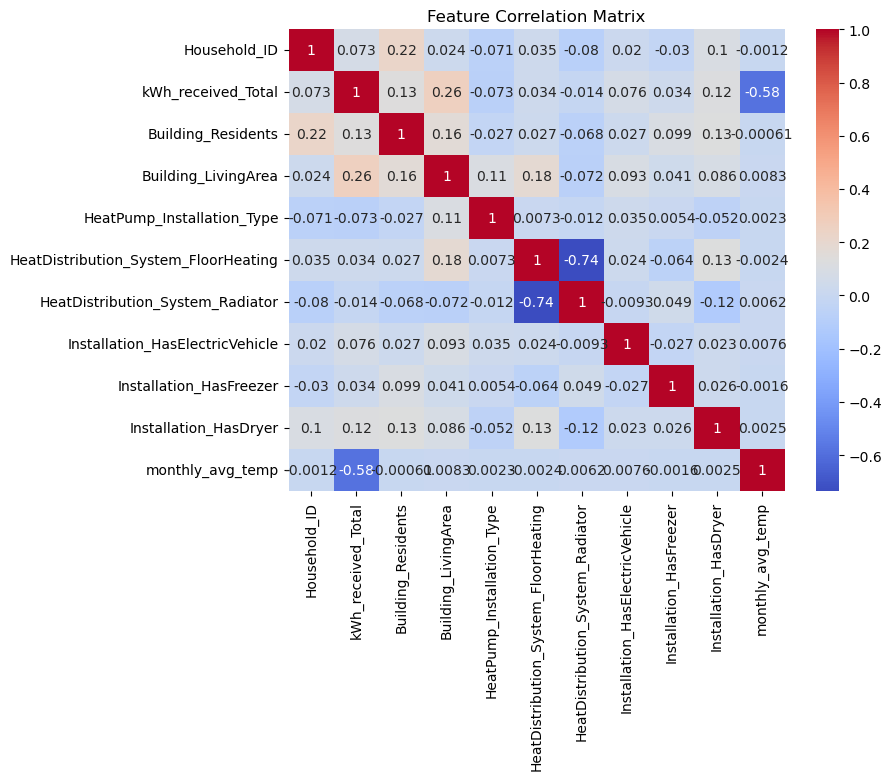

In [21]:
# correlation heatmap
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

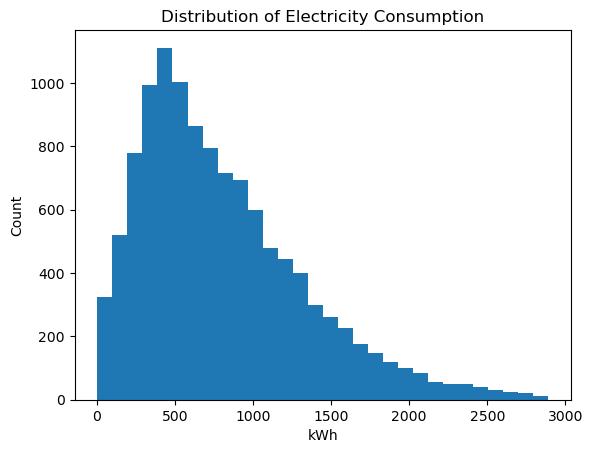

In [22]:
# How is electricity consumption distributed
plt.figure()
plt.hist(df['kWh_received_Total'], bins=30)
plt.xlabel('kWh')
plt.ylabel('Count')
plt.title('Distribution of Electricity Consumption')
plt.show()

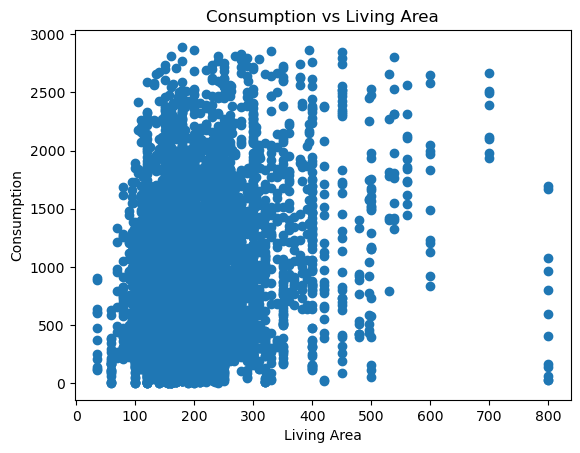

In [23]:
# Consumption vs Living Area
plt.figure()
plt.scatter(df['Building_LivingArea'], df['kWh_received_Total'])
plt.xlabel('Living Area')
plt.ylabel('Consumption')
plt.title('Consumption vs Living Area')
plt.show()

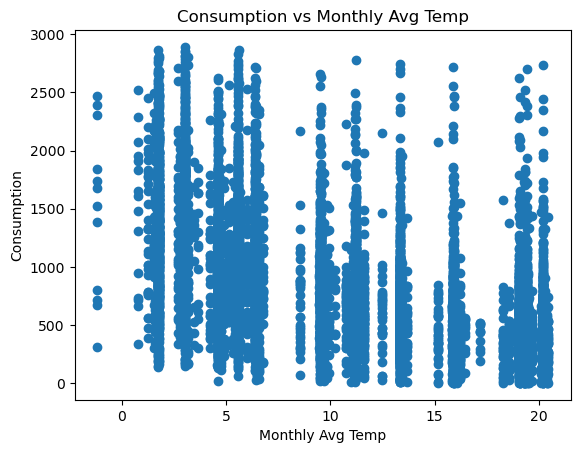

In [24]:
# Consumption vs Monthly_avg_temp
plt.figure()
plt.scatter(df['monthly_avg_temp'], df['kWh_received_Total'])
plt.xlabel('Monthly Avg Temp')
plt.ylabel('Consumption')
plt.title('Consumption vs Monthly Avg Temp')
plt.show()

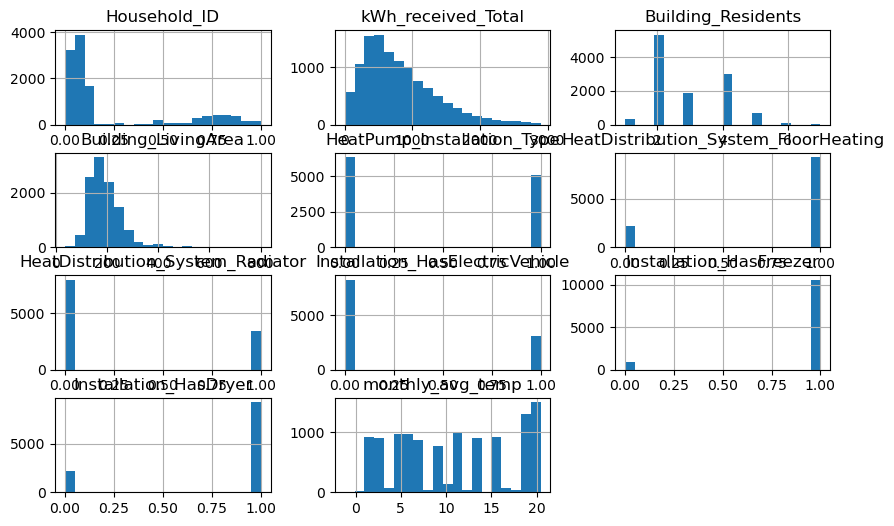

In [25]:
# Feature distributions
df.hist(figsize=(10, 6), bins=20)
plt.show()

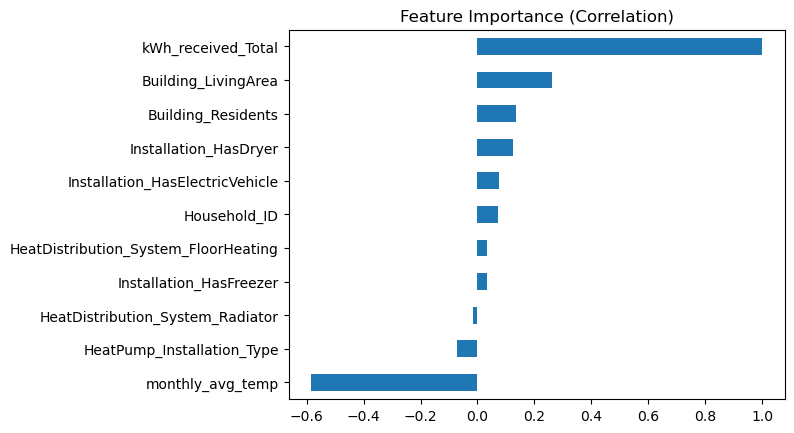

In [26]:
df.corr(numeric_only=True)['kWh_received_Total'].sort_values().plot(kind='barh')
plt.title('Feature Importance (Correlation)')
plt.show()


**Which features matter most**

**Monthly average temperature** → strongest predictor

**Living area** → second predictor

**Residents** → third predictor

**Heating system and the rest** → smaller effect


## Regression
### Linear Regression

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


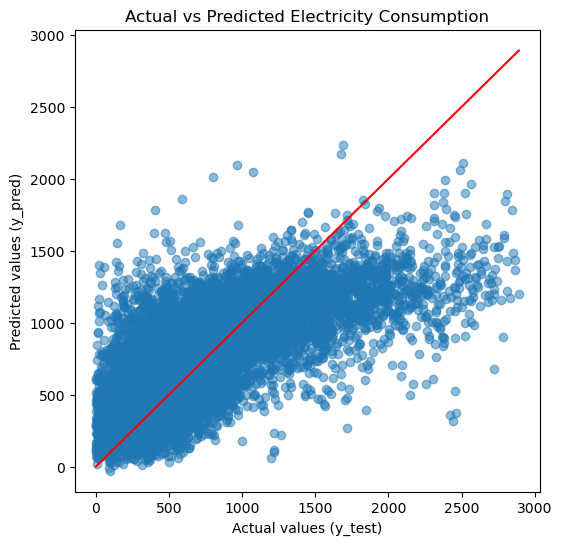

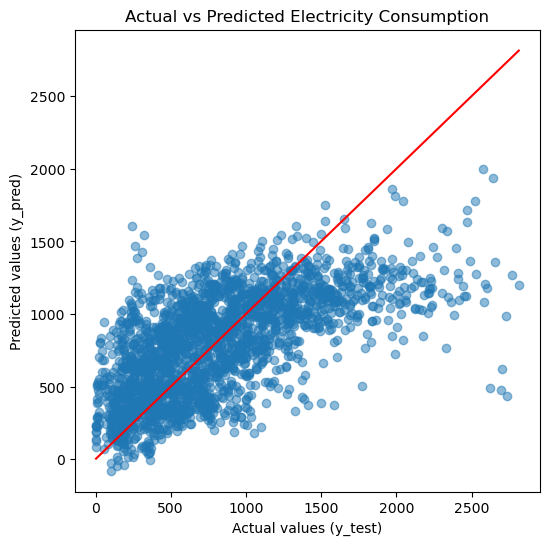

In [39]:
# 1. Define features (X) and target (y)
X = df.drop(columns = ['kWh_received_Total','Household_ID'])
y = df['kWh_received_Total']

# 2. Train-test split
# Split using Household_ID
households = df["Household_ID"].unique()

train_households, test_households = train_test_split(households, test_size=0.2, random_state=42)
train_df = df[df["Household_ID"].isin(train_households)]
test_df  = df[df["Household_ID"].isin(test_households)]

#Remove target AND ID from features
X_train = train_df.drop(columns=["kWh_received_Total", "Household_ID"])
y_train = train_df["kWh_received_Total"]

X_test = test_df.drop(columns=["kWh_received_Total", "Household_ID"])
y_test = test_df["kWh_received_Total"]

#Scale properly
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#3. Create model
model = LinearRegression()

#4. Train model
model.fit(X_train, y_train)

def compute_metrics(model, X, Y):
    #5. Make predictions
    y_pred = model.predict(X)
    
    # 6. Evaluate model
    mae = mean_absolute_error(Y, y_pred)
    rmse = np.sqrt(mean_squared_error(Y, y_pred))
    r2 = r2_score(Y, y_pred)
    return mae, rmse, r2
    
    print(f"Results {model}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)

def plot_predictions(model, X, y):
    y_pred = model.predict(X)
    plt.figure(figsize=(6,6))
    plt.scatter(y, y_pred, alpha=0.5)
    
    plt.xlabel("Actual values (y_test)")
    plt.ylabel("Predicted values (y_pred)")
    plt.title("Actual vs Predicted Electricity Consumption")
    
    # diagonal reference line (perfect prediction)
    plt.plot([y.min(), y.max()],
             [y.min(), y.max()],
             color='red')
    
    plt.show()    

compute_metrics(model, X_train, y_train)
mae_lr, rmse_lr, r2_lr = compute_metrics(model, X_test, y_test)
mae_lr, rmse_lr, r2_lr 
plot_predictions(model, X_train, y_train)
plot_predictions(model, X_test, y_test)

In [ ]:
#train_df
#test_df

### Random Forest

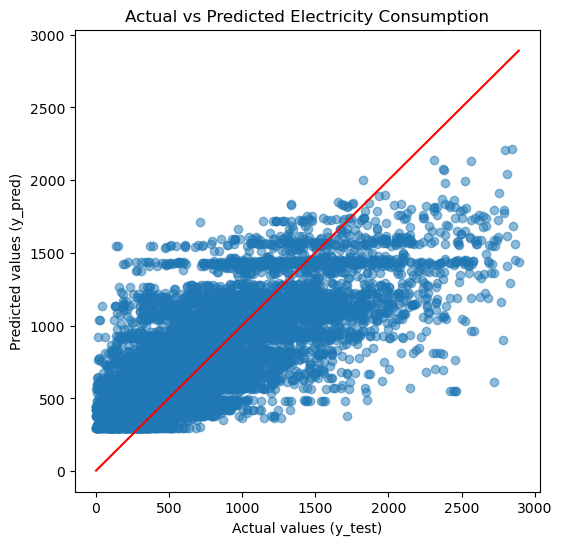

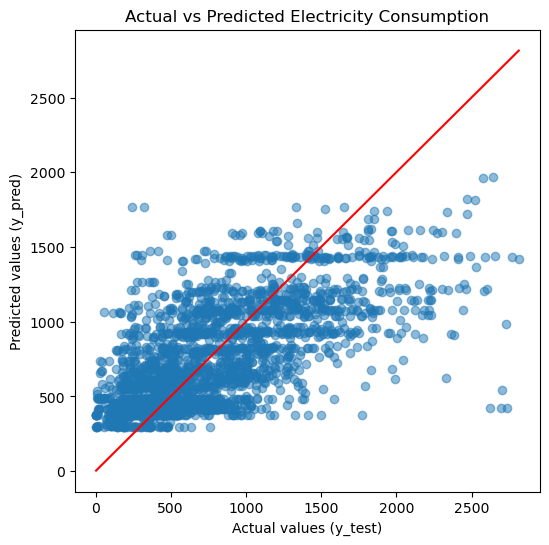

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Create model
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# 2. Train model
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3. Predictions
compute_metrics(rf, X_train, y_train)
mae_rf, rmse_rf, r2_rf = compute_metrics(rf, X_test, y_test)
plot_predictions(rf, X_train, y_train)
plot_predictions(rf, X_test, y_test)

## Polynomial Regression Code


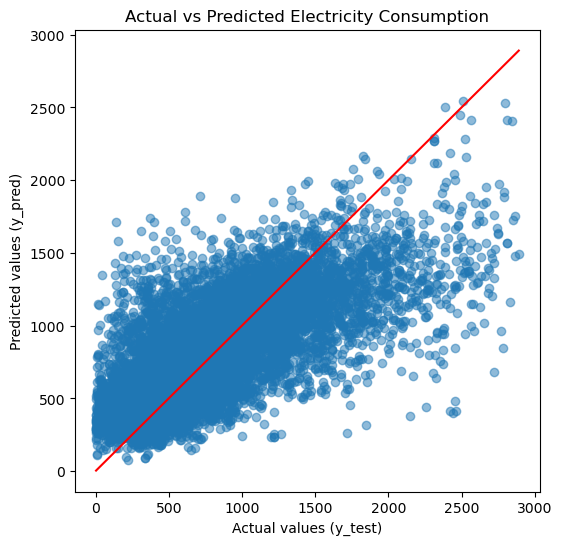

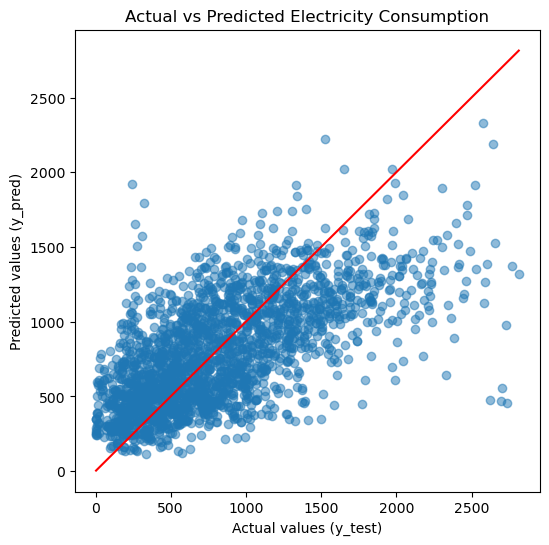

In [41]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

# 1. Create model
poly = PolynomialFeatures(degree=2) 
# 2. Train model
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

model_poly = Ridge(alpha=0.1)
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

# 3. Predictions
compute_metrics(model_poly, X_train_poly, y_train)
mae_pr, rmse_pr, r2_pr = compute_metrics(model_poly, X_test_poly, y_test)
plot_predictions(model_poly, X_train_poly, y_train)
plot_predictions(model_poly, X_test_poly, y_test)


In [44]:
# Create comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Polynomial Ridge"],
    "MAE": [mae_lr, mae_rf, mae_pr],
    "RMSE": [rmse_lr, rmse_rf, rmse_pr],
    "R²": [r2_lr, r2_rf, r2_pr]
})

results = results.round()
print(results)

               Model      MAE     RMSE     R²
0  Linear Regression  312.881  411.097  0.405
1      Random Forest  311.044  409.597  0.409
2   Polynomial Ridge  310.862  408.113  0.414


**Result shows:**

simple linear model ≈ complex model

→ data has limited predictive signal

**The results suggest that household characteristics alone are insufficient to fully explain electricity consumption, and additional dynamic features such as temporal patterns would be required for higher accuracy.**

## Classification with Logistic Regression

We convert consumption into:

**low** (0)
**medium** (1)
**high** (2)

In [46]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# splits data into 3 equal groups
y_class = pd.qcut(y, q=3, labels=[0, 1, 2])
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))

Logistic Regression Results:
Accuracy: 0.6329391151992991
Precision: 0.6221290216661572
Recall: 0.6329391151992991


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


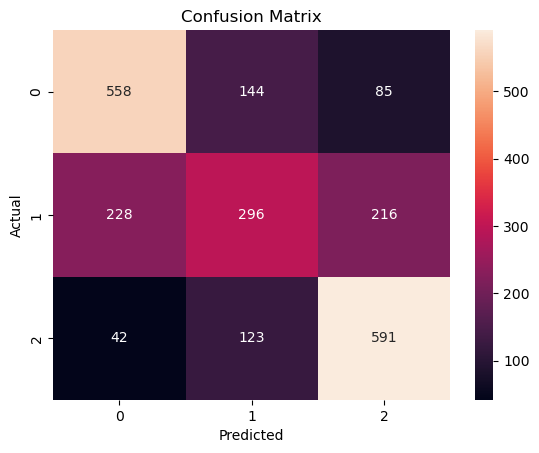

In [47]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

The model performs well on low and high consumption households, but struggles with the medium class. This indicates that energy consumption behaves as a continuous variable rather than discrete categories, making class separation challenging